# 🌶️ Spices Trade and Consumption Analysis  
© Ihor Shvets

## 🎯 Project Title
**Global Spices Flow: Tracking Trade, Consumption, and Logistical Transformation (1995–2023)**

## 🧭 Objective
To explore the transformation of countries' roles in the global spice trade, identifying which shifted from net importers to net exporters (or vice versa), and how these shifts correlate with internal consumption trends and trade volumes.

## ❓ Research Questions
- Which countries experienced the most significant **logistical transformation** in spice trade status (importer ⇄ exporter)?
- What are the long-term **net trade balances** of the world's largest economies?
- How does **spice consumption structure** vary globally? What spices dominate?
- Are there **trade correlations** between specific country pairs that indicate dependency or synchronized trade patterns?

## 📌 Key Findings
- **Most dynamic countries:** Cameroon, Niger, Cambodia (most status changes); Viet Nam and Malaysia (strongest positive shifts).

- **Trade balances:** China is a major net exporter (+427K tons); the U.S. is a heavy net importer (–844K tons).

- **Spice consumption:** Over 83% of global spice use is *Capsicum spp.* (chilies).

- **Trade correlations:** Strong links between China and the U.S., plus regional clusters show dependency patterns.



## 📌 Top 5 countries with the most significant logistical transformation:


In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Spices dataset.csv")
df.columns = df.columns.str.strip().str.lower()

# Calculate trade balance
df['trade_balance'] = df['export'] - df['import']

# Aggregate all spices by country and year
pivot = df.groupby(['area', 'year'])[['import', 'export', 'trade_balance', 'consumption']].sum().reset_index()

# Define status 
pivot['status'] = pivot['trade_balance'].apply(lambda x: 'exporter' if x > 0 else 'importer')

status_change = pivot.groupby('area')['status'].nunique().reset_index()
switched_countries = status_change[status_change['status'] > 1]['area'].tolist()

# Filter 
status_stats = pivot[pivot['area'].isin(switched_countries)].copy()

# Average trade balance
avg_by_status = status_stats.groupby(['area', 'status'])['trade_balance'].mean().unstack()

# absolute shift in balance
avg_by_status['balance_shift'] = (avg_by_status['exporter'] - avg_by_status['importer']).abs()

# Top 5 countries with the highest shift
top5 = avg_by_status.sort_values(by='balance_shift', ascending=False).head(5)
top5_countries = top5.index.tolist()

# Output result with signature
print("📌 Top 5 countries with the most significant logistical transformation:\n")
print(top5[['balance_shift']])
print("\n© Ihor Shvets | Data Analyst")

📌 Top 5 countries with the most significant logistical transformation:

status    balance_shift
area                   
Viet Nam  130191.403571
Malaysia  105305.268667
Israel     67766.851200
Peru       49741.340595
Poland     49483.147667

© Ihor Shvets | Data Analyst


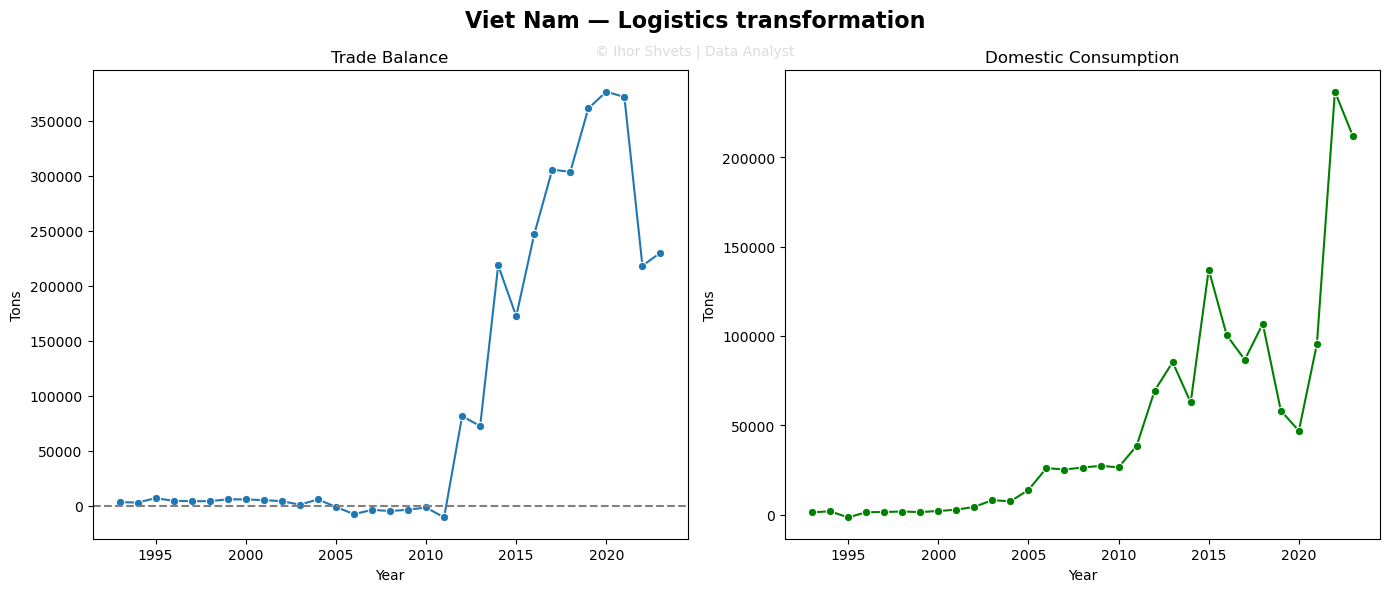

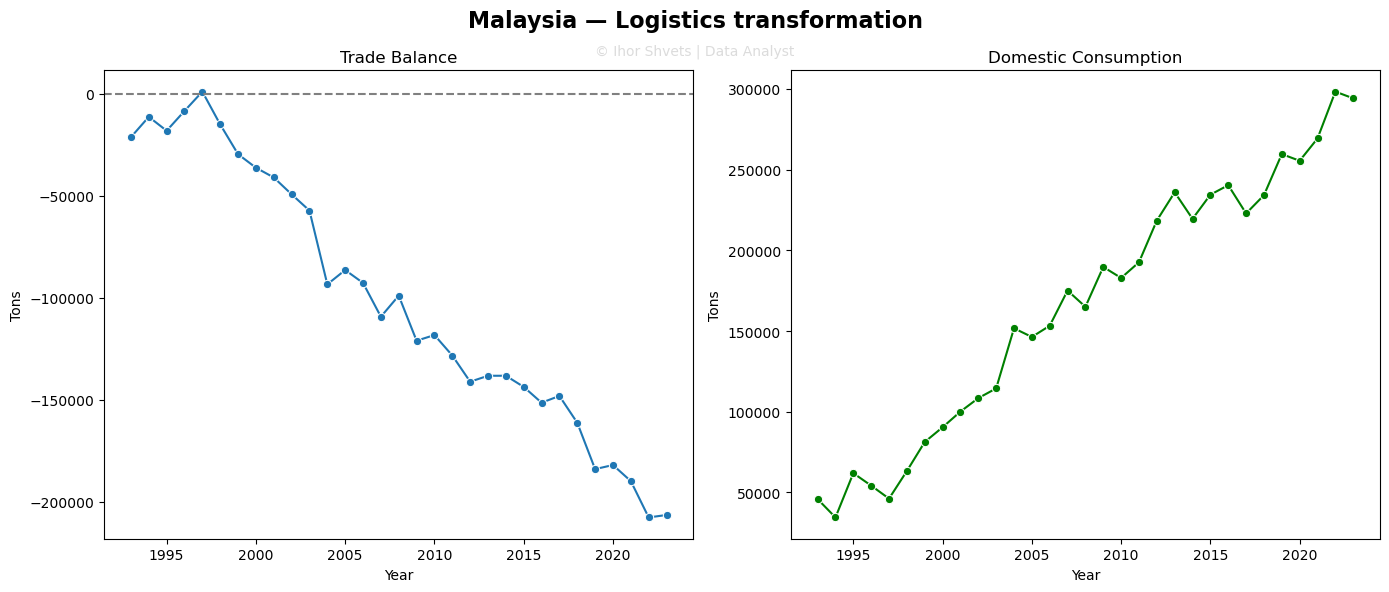

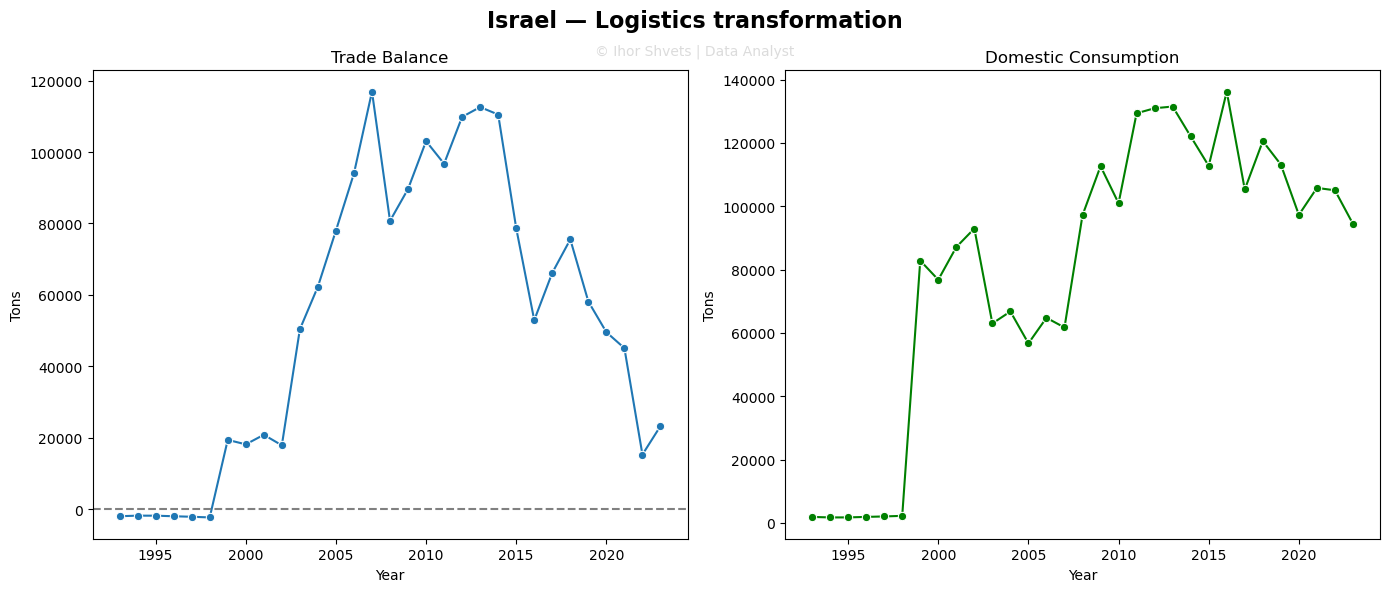

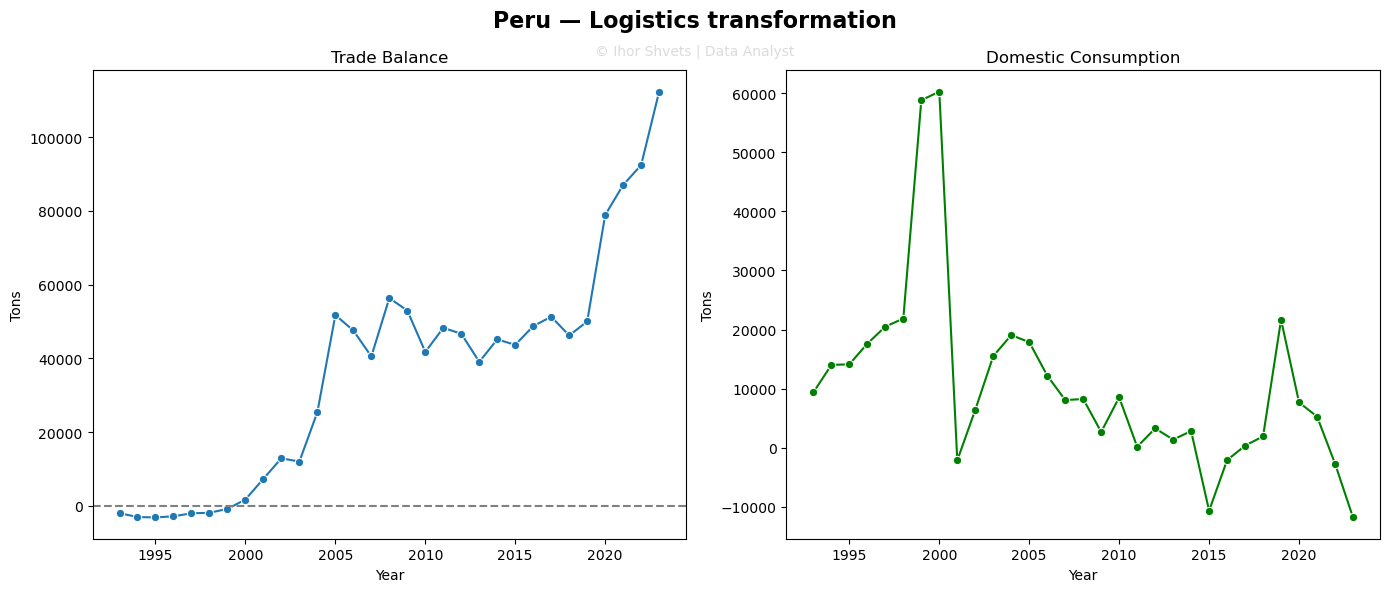

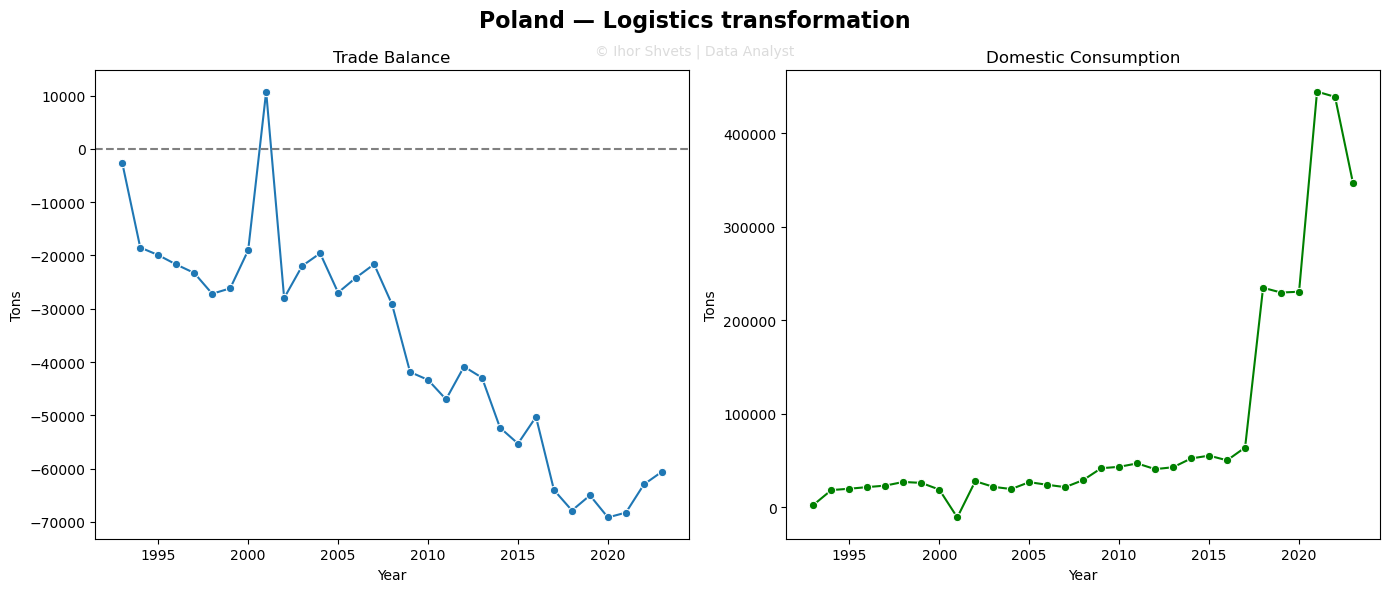

In [4]:
for country in top5_countries:
    df_country = pivot[pivot['area'] == country]

    fig = plt.figure(figsize=(14, 6))
    plt.suptitle(f"{country} — Logistics transformation", fontsize=16, weight='bold')

    # ✅ Watermark below title, centered
    fig.text(
        0.5, 0.91, "© Ihor Shvets | Data Analyst",
        ha='center', va='center',
        fontsize=10, color='lightgray', alpha=0.8
    )

    # Trade Balance
    plt.subplot(1, 2, 1)
    sns.lineplot(data=df_country, x='year', y='trade_balance', marker='o')
    plt.axhline(0, color='gray', linestyle='--')
    plt.title("Trade Balance")
    plt.xlabel("Year")
    plt.ylabel("Tons")

    # Consumption
    plt.subplot(1, 2, 2)
    sns.lineplot(data=df_country, x='year', y='consumption', marker='o', color='green')
    plt.title("Domestic Consumption")
    plt.xlabel("Year")
    plt.ylabel("Tons")

    plt.tight_layout()
    plt.show()


## 📅 Status change table (first 10 entries) Importer <-> Exporter


In [44]:
# 1. Prepare pivot table: calculate trade balance
df['trade_balance'] = df['export'] - df['import']

pivot = df.groupby(['area', 'year'], as_index=False)[['import', 'export', 'trade_balance']].sum()

# 2. Add trade status (exporter or importer)
status_history = pivot[['area', 'year', 'trade_balance']].copy()
status_history['status'] = status_history['trade_balance'].apply(lambda x: 'exporter' if x > 0 else 'importer')

# 3. Identify years when a status change occurred
change_rows = []

for country, group in status_history.groupby('area'):
    group = group.sort_values('year')
    prev_status = None
    for _, row in group.iterrows():
        current_status = row['status']
        if prev_status is not None and current_status != prev_status:
            change_rows.append({
                'country': country,
                'from_status': prev_status,
                'to_status': current_status,
                'year_of_change': int(row['year'])
            })
        prev_status = current_status

change_table = pd.DataFrame(change_rows)

# 4. Identify top 5 countries with the highest number of status changes
top_changers = (
    change_table.groupby('country')
    .size()
    .reset_index(name='times_status_changed')
    .sort_values(by='times_status_changed', ascending=False)
    .head(5)
)

top_countries = top_changers['country'].tolist()

# 5. Display status change table for top 5 most dynamic countries
top_change_table = change_table[change_table['country'].isin(top_countries)]

print("📅 Status change table:")
display(top_change_table.sort_values(['country', 'year_of_change']))

# ✅ Author signature
print("\n© Ihor Shvets | Data Analyst")

📅 Status change table:


,country,from_status,to_status,year_of_change
51,Cambodia,importer,exporter,1997
52,Cambodia,exporter,importer,1998
53,Cambodia,importer,exporter,1999
54,Cambodia,exporter,importer,2000
55,Cambodia,importer,exporter,2002
56,Cambodia,exporter,importer,2011
57,Cambodia,importer,exporter,2013
58,Cambodia,exporter,importer,2015
59,Cambodia,importer,exporter,2016
60,Cambodia,exporter,importer,2021



© Ihor Shvets | Data Analyst


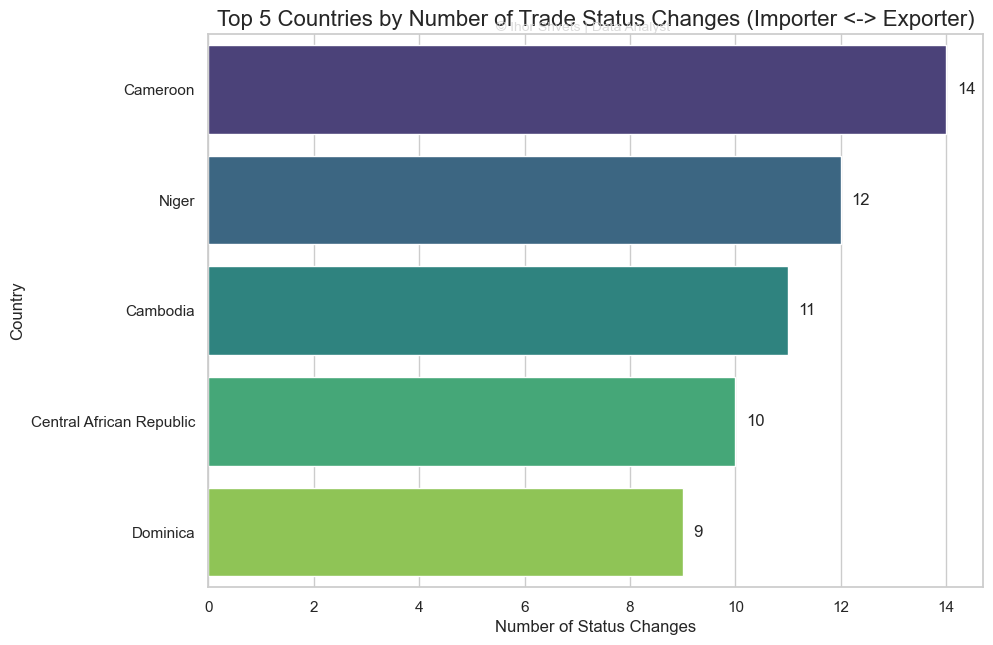

In [26]:
# 1. Building a table of the top 5 countries by the number of status changes
top_changers = (
    change_table.groupby('country')
    .size()
    .reset_index(name='times_status_changed')
    .sort_values(by='times_status_changed', ascending=False)
    .head(5)
)

# 2. Plot
fig = plt.figure(figsize=(10, 7))  # <-- потрібен fig для watermark
sns.set(style="whitegrid")

sns.barplot(
    data=top_changers,
    x='times_status_changed',
    y='country',
    hue='country',
    palette='viridis',
    legend=False
)

for _, row in top_changers.iterrows():
    plt.text(row['times_status_changed'] + 0.2, row['country'], str(row['times_status_changed']),
             va='center', fontsize=12)

plt.title("Top 5 Countries by Number of Trade Status Changes (Importer <-> Exporter)", fontsize=16)

# ✅ Watermark under the title (centered, light gray)
fig.text(
    0.5, 0.91, "© Ihor Shvets | Data Analyst",
    ha='center', va='center',
    fontsize=10, color='lightgray', alpha=0.8
)

plt.xlabel("Number of Status Changes")
plt.ylabel("Country")
plt.subplots_adjust(top=0.9)
plt.show()


## USA vs China: Spice Import and Export (Tons)

/var/folders/mz/6xfyc6kx60vc8c2xs0kfzpgc0000gn/T/ipykernel_11372/2857879679.py:25: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


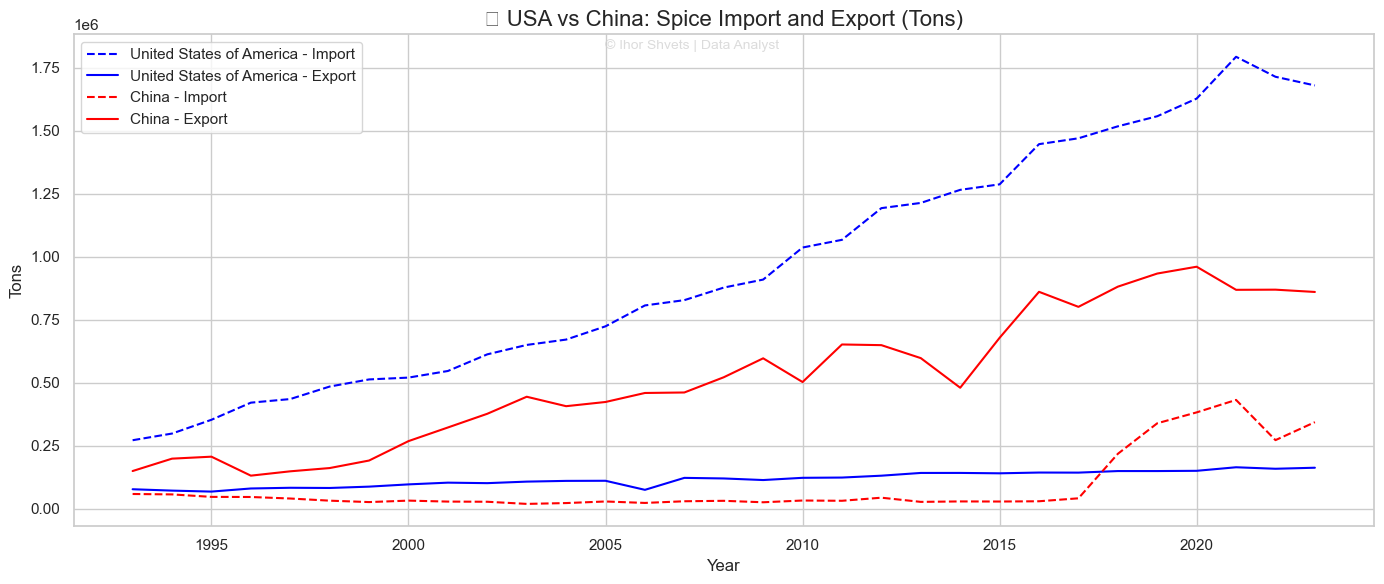

In [28]:
# Data for the USA and China
us_china = pivot[pivot['area'].isin(['United States of America', 'China'])]

# Import and export trends
fig = plt.figure(figsize=(14, 6))  # <-- capture figure object for watermark

for country, color in zip(['United States of America', 'China'], ['blue', 'red']):
    data = us_china[us_china['area'] == country]
    plt.plot(data['year'], data['import'], label=f"{country} - Import", color=color, linestyle='--')
    plt.plot(data['year'], data['export'], label=f"{country} - Export", color=color)

plt.title("📦 USA vs China: Spice Import and Export (Tons)", fontsize=16)

# ✅ Watermark under title (centered, light gray)
fig.text(
    0.5, 0.91, "© Ihor Shvets | Data Analyst",
    ha='center', va='center',
    fontsize=10, color='lightgray', alpha=0.8
)

plt.xlabel("Year")
plt.ylabel("Tons")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Correlation of Spice Imports Between Countries

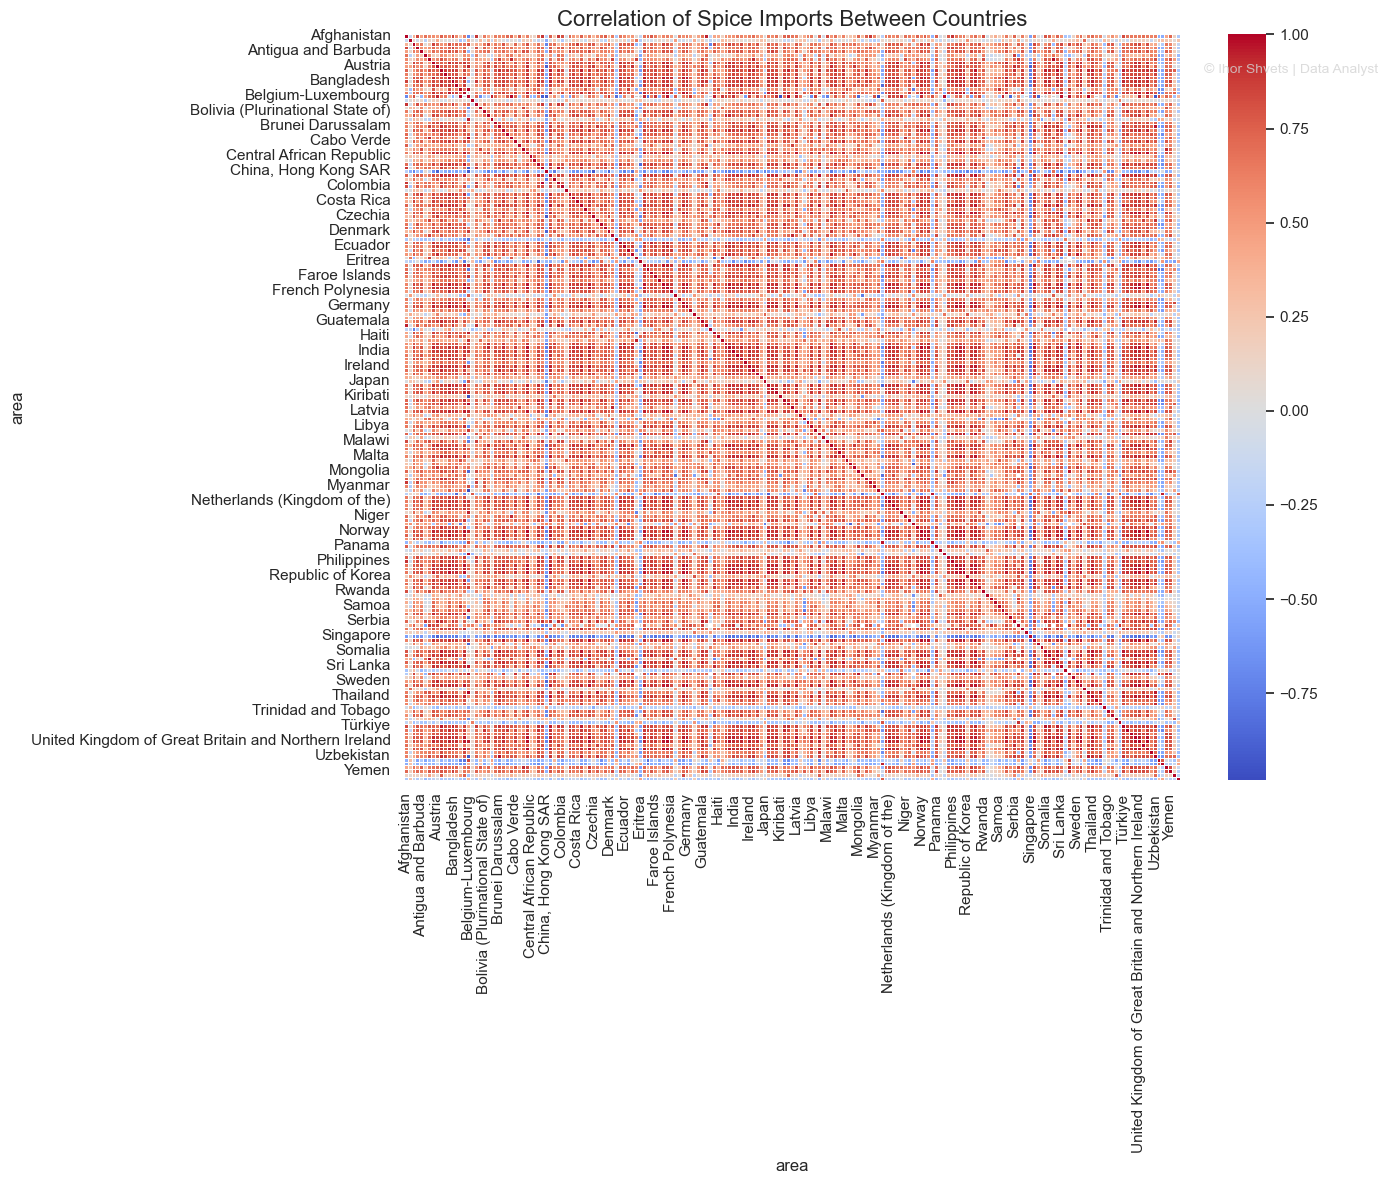

In [32]:
# Pivot table for import correlation
corr_df = pivot.pivot(index='year', columns='area', values='import')

# Correlation heatmap
fig = plt.figure(figsize=(14, 12))
sns.heatmap(corr_df.corr(), cmap='coolwarm', annot=False, linewidths=0.5)

plt.title("Correlation of Spice Imports Between Countries", fontsize=16)

# ✅ Watermark to the right of the title (top right corner)
fig.text(
    0.99, 0.935, "© Ihor Shvets | Data Analyst",
    ha='right', va='center',
    fontsize=10, color='lightgray', alpha=0.8
)

plt.tight_layout()
plt.show()


In [46]:
# Calculate net trade balance (export-import)
pivot['net_trade_balance'] = pivot['export'] - pivot['import']

selected_countries = ['United States of America', 'China']
net_balance = (
    pivot[pivot['area'].isin(selected_countries)]
    .groupby('area')['net_trade_balance']
    .mean()
    .reset_index()
    .rename(columns={'net_trade_balance': 'avg_net_trade_balance'})
)
display(net_balance)
# ✅ Author signature
print("\n© Ihor Shvets | Data Analyst")

,area,avg_net_trade_balance
0,China,427374.959032
1,United States of America,-844462.945806



© Ihor Shvets | Data Analyst


## Average Net Trade Balance (Export - Import)\nUSA vs China (Tons)

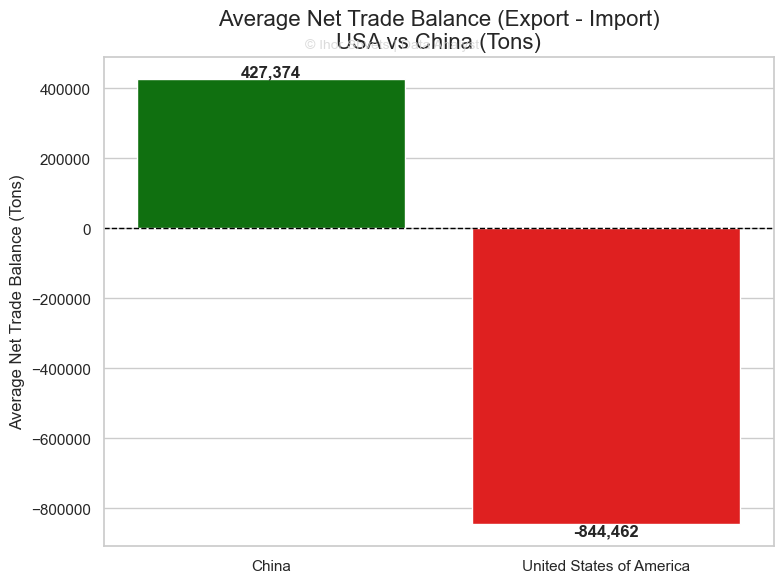

In [34]:
fig = plt.figure(figsize=(8, 6))  # capture figure for watermark
sns.set(style="whitegrid")

net_balance['color'] = ['red' if x < 0 else 'green' for x in net_balance['avg_net_trade_balance']]

sns.barplot(
    data=net_balance,
    x='area',
    y='avg_net_trade_balance',
    hue='area',
    palette=dict(zip(net_balance['area'], net_balance['color'])),
    legend=False
)

# Label bars
for i, row in net_balance.iterrows():
    plt.text(i, row['avg_net_trade_balance'], f"{int(row['avg_net_trade_balance']):,}", 
             ha='center', 
             va='bottom' if row['avg_net_trade_balance'] > 0 else 'top', 
             fontsize=12, fontweight='bold')

plt.title("Average Net Trade Balance (Export - Import)\nUSA vs China (Tons)", fontsize=16)

# ✅ Watermark just below the title (centered)
fig.text(
    0.5, 0.91, "© Ihor Shvets | Data Analyst",
    ha='center', va='center',
    fontsize=10, color='lightgray', alpha=0.8
)

plt.xlabel("")
plt.ylabel("Average Net Trade Balance (Tons)")
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


## Share of Each Spice in Total Consumption (%)

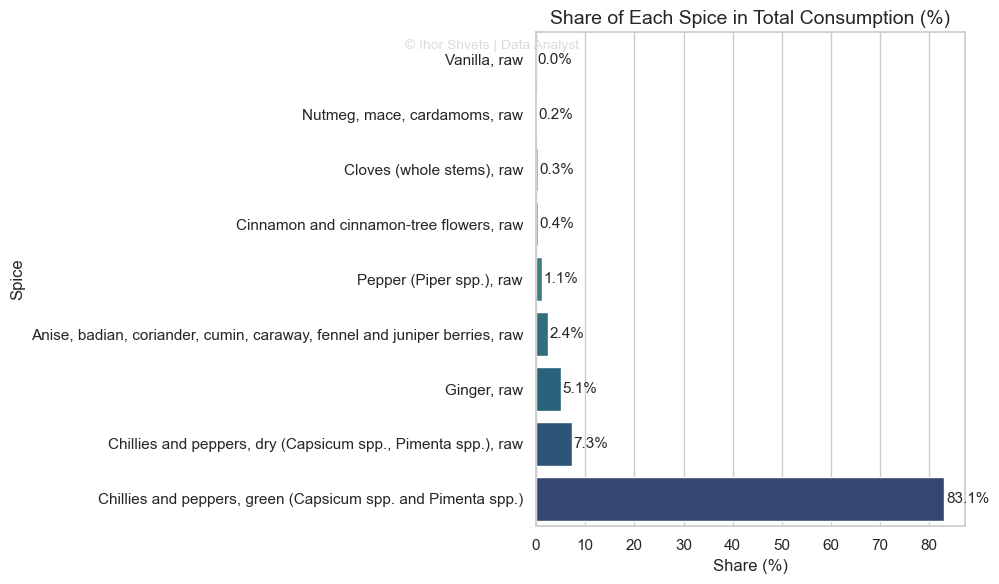

In [36]:
item_consumption = df.groupby('item')['consumption'].sum().sort_values(ascending=True)
item_share = (item_consumption / item_consumption.sum()) * 100
item_share_df = item_share.reset_index(name='share')

# Create figure
fig = plt.figure(figsize=(10, 6))
sns.set(style="whitegrid")

sns.barplot(
    data=item_share_df,
    x='share',
    y='item',
    hue='item',
    dodge=False,
    legend=False,
    palette='crest'
)

# Add value labels
for i, v in enumerate(item_share.values):
    plt.text(v + 0.3, i, f"{v:.1f}%", va='center', fontsize=11)

plt.title("Share of Each Spice in Total Consumption (%)", fontsize=14)

# ✅ Watermark under title (centered)
fig.text(
    0.5, 0.91, "© Ihor Shvets | Data Analyst",
    ha='center', va='center',
    fontsize=10, color='lightgray', alpha=0.8
)

plt.xlabel("Share (%)")
plt.ylabel("Spice")
plt.tight_layout()
plt.show()
